In [2]:
# idk havent found a better way sorry
import os, sys
sys.path.insert(0, os.path.abspath("../.."))

import numpy as np
import matplotlib.pyplot as plt
from src import fdm_schemes
from src.iter_schemes import jacobi, gauss_seidel, sor


In [ ]:
L = 1.0
N = 100
dx = L / N
dt = 0.001
T = 10.0
c = 1.0


u0 = np.sin(np.pi * np.linspace(0, L, N))

res = fdm_schemes.wave_equation_1d(u0, c, dx, dt, T)

In [ ]:
plt.imshow(res, aspect='auto', extent=[0, L, T, 0])

In [ ]:
plt.plot(res)

## 1.6 

### H

In [ ]:
N= 50

cJ, dJ = jacobi(N)
cG, dG = gauss_seidel(N)
cS, dS, _ = sor(N, omega=1.8)   


In [ ]:
y = np.linspace(0, 1, N)      # i think?   
analytic = y                     

profJ = cJ.mean(axis=0)
profG = cG.mean(axis=0)
profS = cS.mean(axis=0)

errJ = np.max(np.abs(profJ - analytic))
errG = np.max(np.abs(profG - analytic))
errS = np.max(np.abs(profS - analytic))

print("Max abs error vs c(y)=y:")
print("Jacobi      :", errJ)
print("Gauss-Seidel:", errG)
print("SOR (1.8)   :", errS)


In [ ]:
plt.figure()
plt.plot(y, analytic, label="Analytical solution")
plt.plot(y, profJ, "--", label="Jacobi")
plt.plot(y, profG, "--", label="Gauss-Seidel")
plt.plot(y, profS, "--", label="SOR ω=1.8")
plt.xlabel("y")
plt.ylabel("c")
plt.legend()
plt.title("Comparison of Iterative Schemes (mean of x) for c(y)=y")
plt.show()


### I

In [ ]:
_, dj_2 = jacobi(N)
_, dg_2 = gauss_seidel(N)

omegas = [1.0, 1.2, 1.5, 1.8, 1.9]
ds_2 = {}
for o in omegas:
    _, ds_2[o], _ = sor(N, omega=o)


In [ ]:
# fix later somehow so that the gs and w=1 sor can be distinguished or ig just rmv that sor
plt.figure(figsize=(7,5))

plt.semilogy(dj_2, label="Jacobi", alpha=0.5)
plt.semilogy(dg_2, label="Gauss–Seidel", alpha=0.5)

for o in omegas:
    plt.semilogy(ds_2[o], label=f"SOR ω={o}", alpha=0.5)

plt.xlabel("k")
plt.ylabel(r"$\delta(k)$")
plt.title("Convergence comparison")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()


### J

Initial best: N=50, ω=1.90, k=197


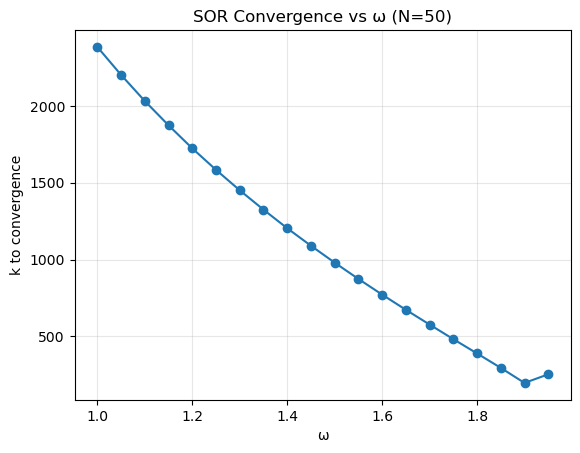

In [8]:
N=50
omegas = np.arange(1.0, 2.0, 0.05) 

ks = []
for o in omegas:
    _, _, k = sor(N, omega=o)
    ks.append(k) 

ks = np.array(ks)

w0 = omegas[np.argmin(ks)]
print(f"Initial best: N={N}, ω={w0:.2f}, k={ks.min()}") # based on min k, cos what else but open to suggestoiins lol

plt.figure()
plt.plot(omegas, ks, marker="o")
plt.xlabel("ω")
plt.ylabel("k to convergence")
plt.title(f"SOR Convergence vs ω (N={N})")
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
# based on initial best, more precise check cos looks like maybe a smalller min somehere there??

w0 = 1.90
omegas_more = np.arange(w0 - 0.08, w0 + 0.081, 0.01) # why 0.08 idk but eh

ks_2 = []
for o in omegas_more:
    _, _, k = sor(N, o)
    ks_2.append(k)

ks_2 = np.array(ks_2)

o_opt = omegas_more[np.argmin(ks_2)]
k_opt = ks_2.min()
print(f"Best: N={N}, ω_opt={o_opt:.2f}, k={k_opt}")

Best: N=50, ω_opt=1.92, k=161


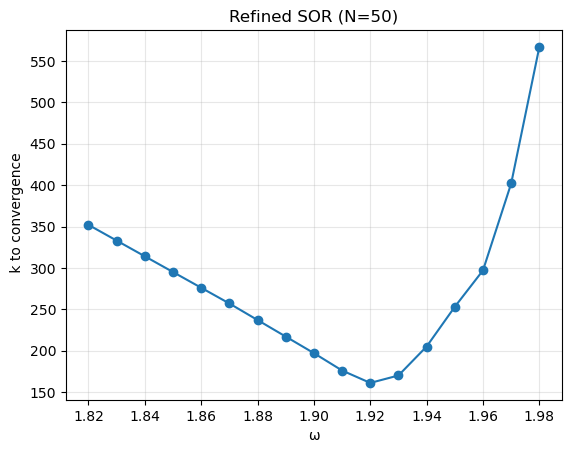

In [11]:
plt.figure()
plt.plot(omegas_more, ks_2, marker="o")
plt.xlabel("ω")
plt.ylabel(" k to convergence")
plt.title(f"Refined SOR Convergence (N={N})")
plt.grid(True, alpha=0.3)
plt.show()


In [15]:
# more properly
Ns = [20, 30, 50, 80, 100] # prob do more later when time
tol = 1e-5
max_iter = 50000

o_opts = []
k_opts = []

for N in Ns:
    omegas = np.arange(1.0, 2.0, 0.05)
    ks = []
    for o in omegas:
        _, _, k = sor(N, omega=o, tol=tol, max_iter=max_iter)
        ks.append(k if k < max_iter else np.inf)
    ks = np.array(ks)

    w0 = omegas[np.argmin(ks)]

    omegas_finer = np.arange(max(1.0, w0-0.08), min(1.99, w0+0.08)+1e-12, 0.01)
    ks_finer = []
    for o in omegas_finer:
        _, _, k = sor(N, omega=o, tol=tol, max_iter=max_iter)
        ks_finer.append(k if k < max_iter else np.inf)
    ks_finer = np.array(ks_finer)

    o_opt = omegas_finer[np.argmin(ks_finer)]
    k_opt = ks_finer.min()

    o_opts.append(o_opt)
    k_opts.append(k_opt)

   



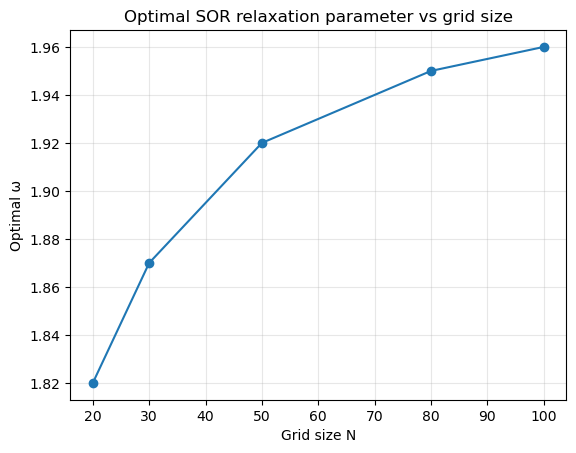

In [17]:
plt.figure()
plt.plot(Ns, o_opts, marker="o")
plt.xlabel("Grid size N")
plt.ylabel("Optimal ω")
plt.title("Optimal SOR relaxation parameter vs grid size")
plt.grid(True, alpha=0.3)
plt.show()